# Rendering a DCT scan

In diffraction contrast tomography (DCT), a box beam lights the whole sample at once, and the detector sits a few millimetres behind it.
Each grain's diffraction spot is then a picture of the grain: its shape, projected along the diffracted beam onto the detector.
As the sample turns, every reflection projects the grain from a different direction, which is what makes the grain shapes recoverable.

The renderer handles this with the same model as scanning 3DXRD. Only the beam (wider than the sample), the voxels (cubes, for a 3D map) and the detector change.
Here we render a full 360° scan of a small polycrystal and look at the frames.

Rendering takes about 15 minutes on a 12-core laptop CPU, so the documentation shows a stored run: it is not re-executed when the docs are built.

In [1]:
import anri.utils
anri.utils.setup()  # before any JAX computation

import time

import jax
import jax.numpy as jnp
import numpy as np
from matplotlib import pyplot as plt
from scipy.spatial.transform import Rotation

import Dans_Diffraction

import anri.crystal, anri.fwd, anri.io

start = time.time()
print(jax.devices())

[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]


## The sample

A cube of 80 × 80 × 80 voxels of 5 µm (400 µm across), split into iron grains: each voxel belongs to the nearest of a few random seed points (a Voronoi tessellation), and each grain has a random orientation.
For a 3D map, every voxel is one entry with its position, UBI and density, as for a 2D map.

512000 voxels in 10 grains


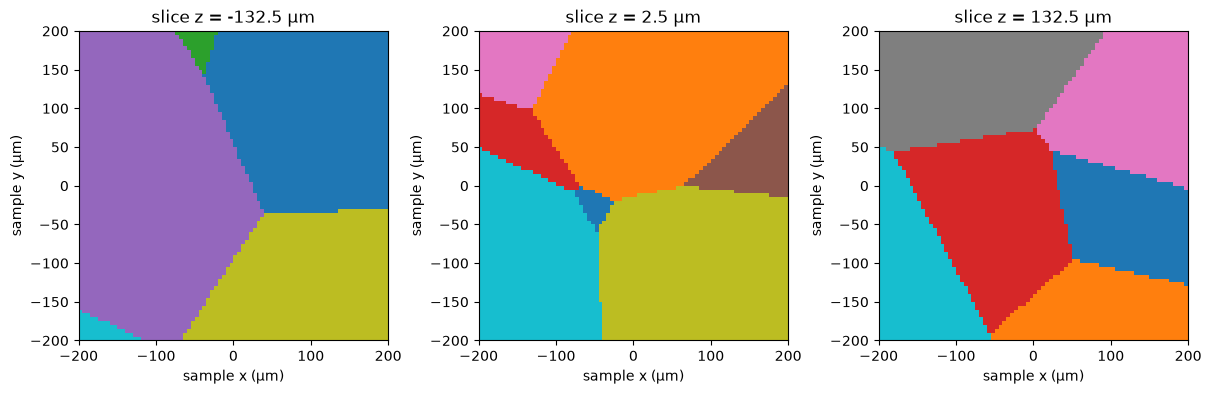

In [2]:
n_side, voxel = 80, 5.0  # voxels per side, voxel size (µm)
n_grains = 10
rng = np.random.default_rng(42)

centres = (np.arange(n_side) - (n_side - 1) / 2) * voxel
pos = np.stack(np.meshgrid(centres, centres, centres, indexing="ij"), axis=-1).reshape(-1, 3)
seeds = rng.uniform(-n_side / 2, n_side / 2, size=(n_grains, 3)) * voxel
grain = np.argmin(((pos[:, None, :] - seeds[None]) ** 2).sum(-1), axis=1)

xtl = Dans_Diffraction.Crystal("../../../tests/data/cif/Fe.cif")  # bcc iron
lattice = anri.crystal.lattice_parameters(xtl)
B = anri.crystal.B_matrix(lattice)
U = Rotation.random(n_grains, random_state=7).as_matrix()
ubi_grain = np.linalg.inv(U @ B)
entries = {"ubi": ubi_grain[grain], "pos": pos, "density": np.ones(len(pos))}
print(len(pos), "voxels in", n_grains, "grains")

labels = grain.reshape(n_side, n_side, n_side)
fig, axs = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for ax, z in zip(axs, (n_side // 6, n_side // 2, 5 * n_side // 6)):
    ax.imshow(labels[:, :, z].T, origin="lower", cmap="tab10", extent=(centres[0] - voxel / 2, centres[-1] + voxel / 2) * 2)
    ax.set(title=f"slice z = {centres[z]:.1f} µm", xlabel="sample x (µm)", ylabel="sample y (µm)")
plt.show()

## Geometry and the scan

A DCT-like setup: 43 keV, a 2048 × 2048 detector with 1 µm pixels, 5 mm behind the sample, and a box beam 600 µm wide in both directions, so that the whole cube (566 µm across its diagonal) is lit at every angle.
`voxel_3d=True` tells the renderer that the voxels are cubes (by default they are columns, for 2D maps).

Moving a voxel by a micron moves its spot by about a micron on the detector, a pixel here, so each spot is a projection of its grain, and where it lands depends on where the grain sits in the sample as much as on the grain's orientation.
The grains are spread over 400 µm, comparable with the radii of the Debye-Scherrer rings on the detector (0.7 to 1.8 mm), so the spots do not fall on rings, and reflections whose rings lie outside the detector can still reach it.
The hkls therefore run out to the detector's corner plus the sample's half diagonal.

The renderer treats each voxel as a point, blurred by the detector's point spread `sig_psf`.
A 5 µm cube covers about 5 pixels, so `sig_psf` here also stands in for the voxel's footprint (5 / √12 ≈ 1.4 px, with ~0.7 px of detector blur): with less, the voxel grid shows through the spots as a lattice of dots.


In [3]:
wavelength = 12.398419843320026 / 43.0  # angstrom
det_shape = (2048, 2048)
pars = {
    "y_center": 1023.5, "y_size": 1.0, "tilt_y": 0.0,
    "z_center": 1023.5, "z_size": 1.0, "tilt_z": 0.0, "tilt_x": 0.0,
    "distance": 5000.0, "o11": -1, "o12": 0, "o21": 0, "o22": -1,
    "wavelength": wavelength, "wedge": 0.0, "chi": 0.0,
}
geom = anri.io.geom_from_pars(
    pars, y0=0.0, sig_wavelength=wavelength * 1e-4, sig_ky=1e-4, sig_kz=1e-4, voxel_size=voxel, sig_psf=1.6,
    sig_beam=0.5, width_beam=600.0, sig_beam_v=0.5, width_beam_v=600.0, voxel_3d=True,
)

# hkls whose spots can reach the detector: out to its corner, plus the sample's half diagonal
reach = np.sqrt(2) * 1024 * pars["y_size"] + np.sqrt(3) * n_side * voxel / 2
tth_max = np.degrees(np.arctan(reach / pars["distance"]))
dsmax = 2 * np.sin(np.radians(tth_max / 2)) / wavelength
refl = anri.crystal.reflections(lattice, anri.crystal.space_group(xtl), wavelength, dsmax)
F2 = anri.crystal.structure_factors(xtl, refl["hkl"], wavelength)
strong = F2 > 0.01  # drop the reflections the atom positions extinguish
hkls = refl["hkl"][strong].astype(float)
F2 = F2[strong]
print(len(hkls), "hkls, 2theta from", *np.unique(np.round(refl["tth"][strong], 1)), "deg")

ostep = 0.1
omega = np.arange(0.0, 360.0, ostep) + ostep / 2
print(len(omega), "frames")

78 hkls, 2theta from 8.2 11.6 14.2 16.4 18.3 deg
3600 frames


/tmp/ipykernel_17768/2601772149.py:19: UserWarning: No isotropic thermal factors (U_iso or B_iso) for Fe: intensities have no Debye-Waller attenuation.
  F2 = anri.crystal.structure_factors(xtl, refl["hkl"], wavelength)


## Rendering

The whole scan is one rotation at one dty: a single "row".
Its ~36 million peaks rendered in one call would need about 60 GB of memory, because `render_row` keeps every peak's pixels until it merges them at the end.
So we render it 10° at a time. Each call renders only the frames of its own range (a peak near the edge of a range is split between the two), so the pieces join without overlap.


In [4]:
t0 = time.time()
chunk = 100  # frames per call: 10 degrees
frame, pixel, value, n_peaks = [], [], [], 0
for k0 in range(0, len(omega), chunk):
    row = anri.fwd.make_row(omega[k0 : k0 + chunk], dty=np.zeros(chunk))  # no dty scan with a box beam
    f, p, v, stats = anri.fwd.render_row(entries, hkls, F2, geom, row, det_shape, window=(3, 9, 9), max_frames=15)
    frame.append(f + k0)
    pixel.append(p)
    value.append(v)
    n_peaks += stats["n_peaks"]
frame, pixel, value = np.concatenate(frame), np.concatenate(pixel), np.concatenate(value)
print(f"{n_peaks} peaks -> {frame.size} sparse pixels in {time.time() - t0:.0f} s")

27938838 peaks -> 33736713 sparse pixels in 784 s


## The whole scan, summed

Adding up all 3600 frames: the spots spread over the whole detector instead of lying on rings, because where a spot lands depends on where its grain is.
The middle stays empty: no spot comes closer to the beam than the {110} ring's radius less the sample's size. (The transmitted beam, which a real DCT detector records there, is not rendered.)


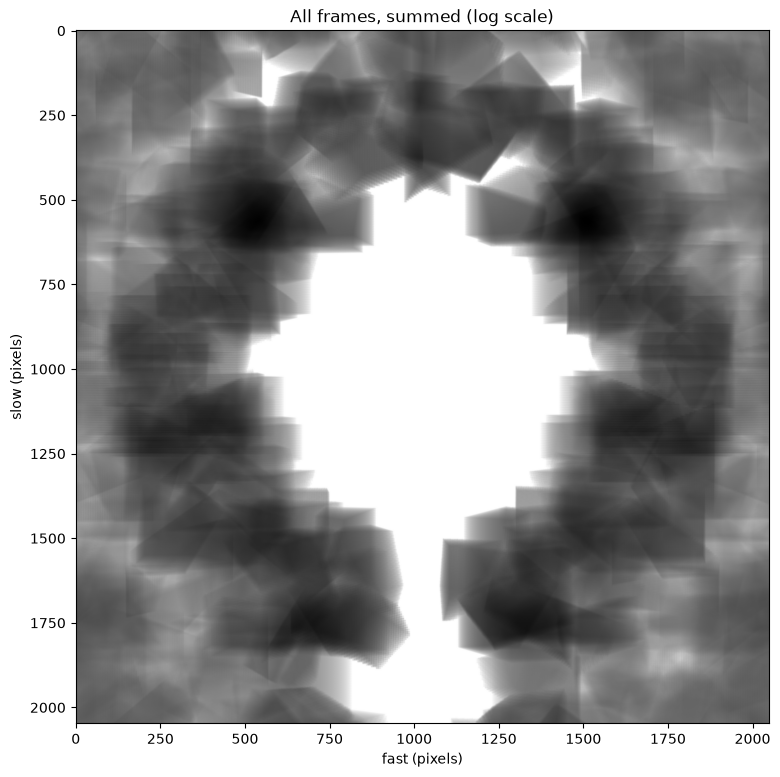

In [5]:
total = np.bincount(pixel, weights=value, minlength=det_shape[0] * det_shape[1]).reshape(det_shape)
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(np.log10(1 + total), cmap="gray_r")
ax.set(title="All frames, summed (log scale)", xlabel="fast (pixels)", ylabel="slow (pixels)")
plt.show()

## Single frames, and a stack

One frame holds only the reflections in the Bragg condition within its 0.1°: a perfect grain diffracts each reflection within a frame or so, so a frame shows just a few spots.
Here are three of the busiest frames, and 10° of frames (100 frames) summed:


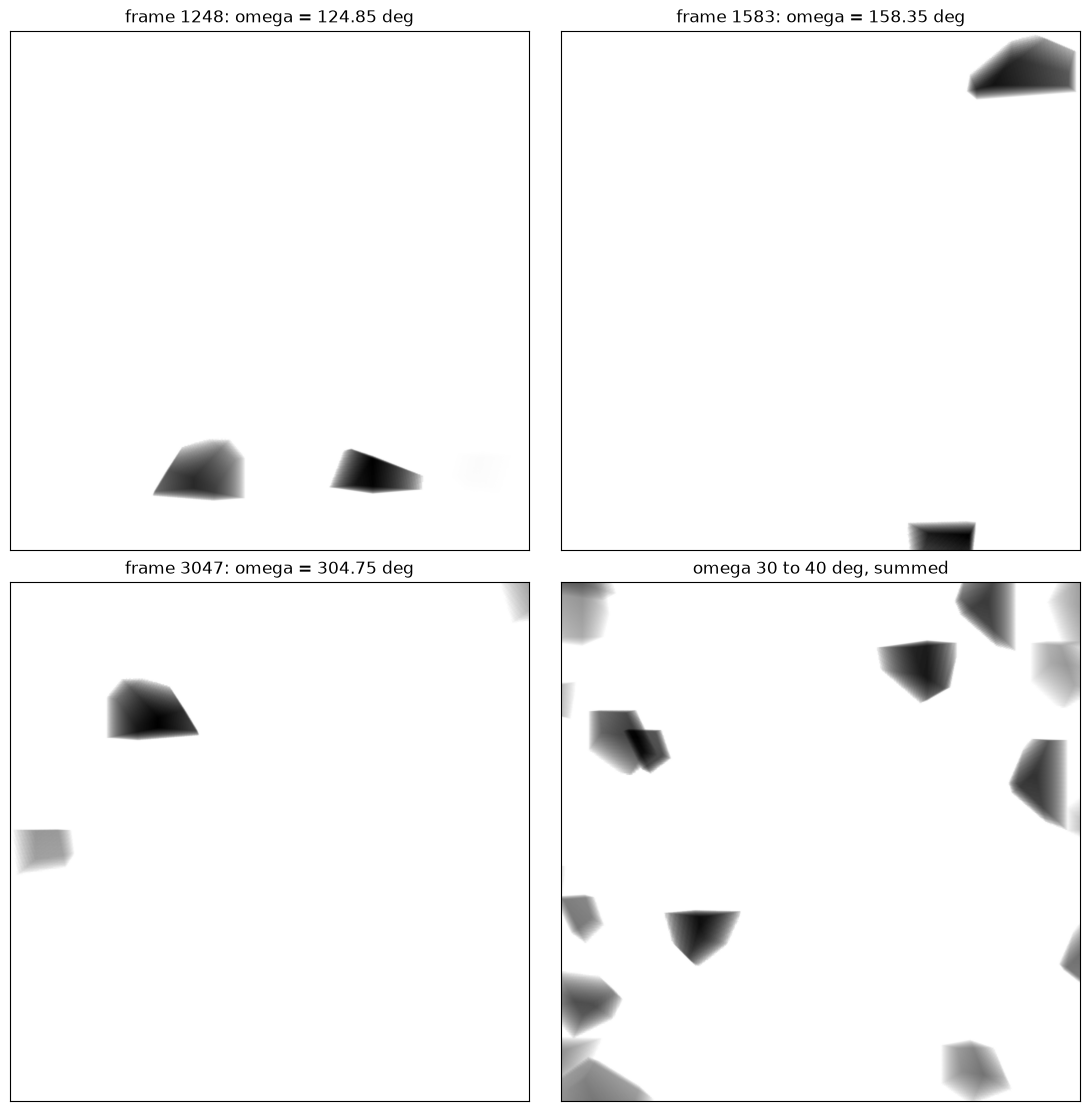

In [6]:
def frame_image(k, n=1):
    m = (frame >= k) & (frame < k + n)
    return np.bincount(pixel[m], weights=value[m], minlength=det_shape[0] * det_shape[1]).reshape(det_shape)

per_frame = np.bincount(frame, weights=value, minlength=len(omega))
busy = np.bincount(frame, minlength=len(omega))  # pixels lit per frame
picks = sorted(np.argsort(busy)[::-1][[0, 5, 10]])
fig, axs = plt.subplots(2, 2, figsize=(11, 11), constrained_layout=True)
for ax, k in zip(axs.ravel(), picks):
    ax.imshow(np.log10(1 + frame_image(k)), cmap="gray_r")
    ax.set(title=f"frame {k}: omega = {omega[k]:.2f} deg", xticks=[], yticks=[])
k0 = 300
axs[1, 1].imshow(np.log10(1 + frame_image(k0, 100)), cmap="gray_r")
axs[1, 1].set(title=f"omega {omega[k0] - ostep / 2:.0f} to {omega[k0 + 99] + ostep / 2:.0f} deg, summed", xticks=[], yticks=[])
plt.show()

## Spots are projections of the grains

Zooming in, each spot has the outline of its grain, as seen along that reflection's diffracted beam.
Each reflection views its grain from a different direction, so a grain's spots differ in shape from one reflection to the next:


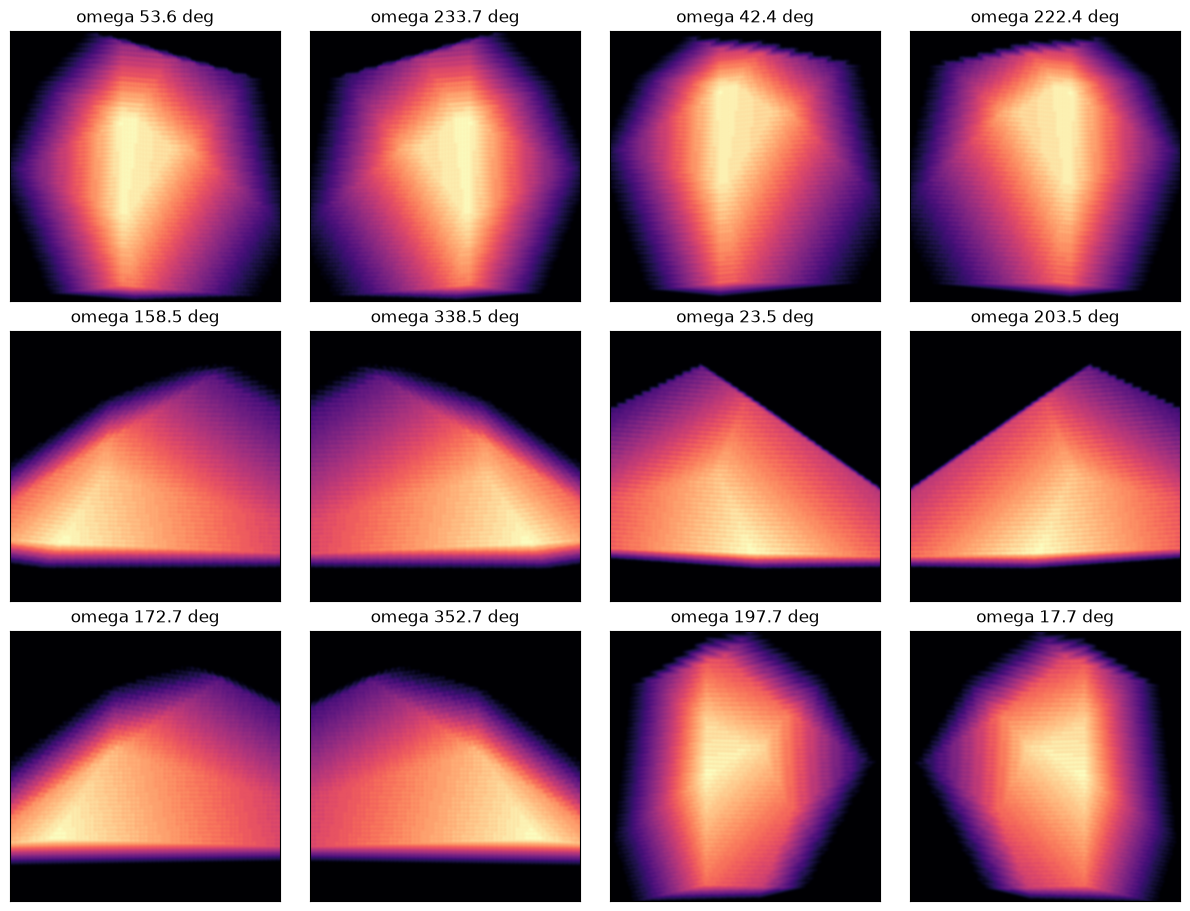

In [7]:
# label connected regions in the brightest frames, and keep the largest
from scipy import ndimage

half = 160  # half-width of the zoomed views (pixels)

def crop(img, cs, cf):
    return np.pad(img, half)[cs : cs + 2 * half, cf : cf + 2 * half]  # padded: spots can touch the edges

spots = []
for k in np.argsort(per_frame)[::-1][:60]:
    img = frame_image(k)
    lab, n = ndimage.label(img > 1e-3 * img.max())
    for i, sl in enumerate(ndimage.find_objects(lab)):
        size = (sl[0].stop - sl[0].start) * (sl[1].stop - sl[1].start)
        spots.append((img[sl].sum(), size, k, sl))
spots = sorted(spots, key=lambda s: -s[1])[:12]  # the largest

fig, axs = plt.subplots(3, 4, figsize=(12, 9), constrained_layout=True)
for ax, (_, _, k, sl) in zip(axs.ravel(), spots):
    cs, cf = (sl[0].start + sl[0].stop) // 2, (sl[1].start + sl[1].stop) // 2
    img = crop(frame_image(k), cs, cf)
    ax.imshow(img, cmap="magma")
    ax.set(title=f"omega {omega[k]:.1f} deg", xticks=[], yticks=[])
plt.show()

To check that a spot really is the projection of its grain, take one of them, find which grain and reflection make it, and put the forward model's centroid of each of that grain's voxels on top.
The cloud of voxel centroids is the grain, projected: it fills the spot.

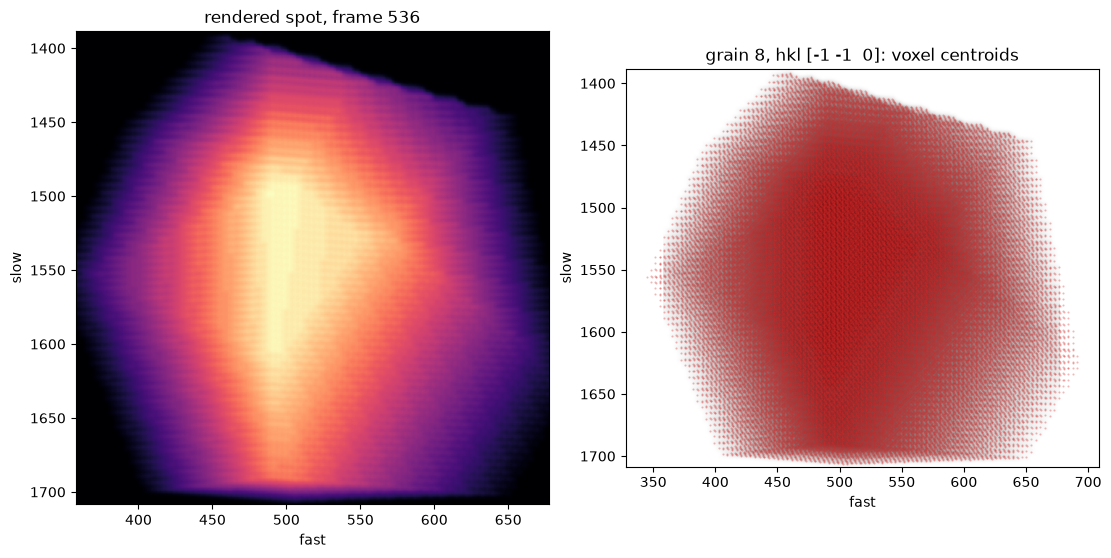

In [8]:
_, _, k, sl = spots[0]
cs, cf = (sl[0].start + sl[0].stop) // 2, (sl[1].start + sl[1].stop) // 2
g = jax.tree.map(jnp.asarray, geom)
args = (g["wavelength"], g["k_in_lab"], 0.0, 0.0, g["wedge"], g["chi"], g["s_step_lab"], g["f_step_lab"], g["det_origin_lab"])

@jax.jit
def centroids(ubi, p, hkl, etasign):
    return jax.vmap(lambda u, q: anri.fwd.get_centroid_box(u, q, hkl, etasign, *args))(ubi, p)

# which (grain, hkl, branch) puts a voxel's centroid into this spot at this omega?
best = None
for gi in range(n_grains):
    sel = np.flatnonzero(grain == gi)[:: max(1, (grain == gi).sum() // 200)]
    for hi in range(len(hkls)):
        for etasign in (1.0, -1.0):
            c, ok = centroids(jnp.asarray(entries["ubi"][sel]), jnp.asarray(pos[sel]), jnp.asarray(hkls[hi]), etasign)
            c = np.asarray(c)
            near = ok & (np.abs(c[:, 0] - cs) < half) & (np.abs(c[:, 1] - cf) < half) & (np.abs(np.mod(c[:, 2] - omega[k] + 180, 360) - 180) < 1.0)
            if near.mean() > (best[0] if best else 0):
                best = (near.mean(), gi, hi, etasign)
_, gi, hi, etasign = best
mine = grain == gi
c, _ = centroids(jnp.asarray(entries["ubi"][mine]), jnp.asarray(pos[mine]), jnp.asarray(hkls[hi]), etasign)
c = np.asarray(c)

img = crop(frame_image(k), cs, cf)
fig, axs = plt.subplots(1, 2, figsize=(11, 5.5), constrained_layout=True)
extent = (cf - half - 0.5, cf + half - 0.5, cs + half - 0.5, cs - half - 0.5)
axs[0].imshow(img, cmap="magma", extent=extent)
axs[0].set(title=f"rendered spot, frame {k}", xlabel="fast", ylabel="slow")
axs[1].imshow(img, cmap="gray_r", extent=extent)
axs[1].scatter(c[:, 1], c[:, 0], s=0.3, c="tab:red", alpha=0.3)
axs[1].set(title=f"grain {gi}, hkl {hkls[hi].astype(int)}: voxel centroids", xlabel="fast", ylabel="slow")
plt.show()

In [9]:
print(f"Took {time.time() - start:.0f} seconds")

Took 792 seconds
